In [1]:
# === Standard Library ===
import os
import gc
import datetime
import warnings
from collections import Counter

# === Data & Math ===
import numpy as np
import pandas as pd
import torch

# === Hugging Face & Transformers ===
import transformers
from huggingface_hub import snapshot_download
from datasets import load_from_disk, Dataset

# === Geneformer ===
from geneformer import EmbExtractor, Classifier
import pickle

# Suppress warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# ==============================
# Environment setup
# ==============================
import os
import sys
import torch
import gc
import warnings 

env_path = "/home/btanasa/miniconda3/envs/torch-cu"
os.environ["CONDA_PREFIX"] = env_path
os.environ["CONDA_DEFAULT_ENV"] = "torch-cu"
os.environ["RETICULATE_PYTHON"] = f"{env_path}/bin/python"
print("✅ Environment set to torch-cu")
print("Python executable:", sys.executable)


print("✅ Environment set to torch_cu")
print("Python executable:", sys.executable)
print("CONDA_PREFIX:", os.environ.get("CONDA_PREFIX"))
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV"))

# Verify the setup
try:
    import torch
    print("✅ PyTorch available:", torch.__version__)
    print("✅ CUDA available:", torch.cuda.is_available())
except ImportError as e:
    print("❌ PyTorch import failed:", e)

try:
    from geneformer import TranscriptomeTokenizer
    print("✅ Geneformer available")
except ImportError as e:
    print("❌ Geneformer import failed:", e)

# Suppress warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Clear GPU cache
torch.cuda.empty_cache()
gc.collect()

# Check GPU memory
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

torch.cuda.empty_cache()
print(f"CUDA memory after empty_cache: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")

print("✅ Environment variable set!")
print(f"PYTORCH_CUDA_ALLOC_CONF: {os.environ.get('PYTORCH_CUDA_ALLOC_CONF')}")
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

print("✅ Environment variable set!")
print(f"PYTORCH_CUDA_ALLOC_CONF: {os.environ.get('PYTORCH_CUDA_ALLOC_CONF')}")


✅ Environment set to torch-cu
Python executable: /home/btanasa/miniconda3/envs/torch-cu/bin/python
✅ Environment set to torch_cu
Python executable: /home/btanasa/miniconda3/envs/torch-cu/bin/python
CONDA_PREFIX: /home/btanasa/miniconda3/envs/torch-cu
CONDA_DEFAULT_ENV: torch-cu
✅ PyTorch available: 2.5.1
✅ CUDA available: True
✅ Geneformer available
GPU memory allocated: 0.00 GB
GPU memory reserved: 0.00 GB
CUDA memory after empty_cache: 0.00 GB
✅ Environment variable set!
PYTORCH_CUDA_ALLOC_CONF: None
✅ Environment variable set!
PYTORCH_CUDA_ALLOC_CONF: expandable_segments:True


In [3]:
# the model was saved in the location :
# /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_out/250821141257/

# model_version1="V1"
model_version2="V2"

token_dictionary_file = "/mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer/geneformer/token_dictionary_gc104M.pkl"  # or your V1 or V2 token dict
token_dict_path = token_dictionary_file

with open(token_dictionary_file, "rb") as f:
    token_dict = pickle.load(f)

print(type(token_dict))
print(len(token_dict))

# Show first 20 entries
for i, (gene, token_id) in enumerate(token_dict.items()):
    print(f"{gene} → {token_id}")
    if i >= 6:
        break

# Convert to DataFrame
token_df = pd.DataFrame(list(token_dict.items()), columns=["Ensembl_ID", "Token_ID"])
print(token_df)


<class 'dict'>
20275
<pad> → 0
<mask> → 1
<cls> → 2
<eos> → 3
ENSG00000000003 → 4
ENSG00000000005 → 5
ENSG00000000419 → 6
            Ensembl_ID  Token_ID
0                <pad>         0
1               <mask>         1
2                <cls>         2
3                <eos>         3
4      ENSG00000000003         4
...                ...       ...
20270  ENSG00000292379     20270
20271  ENSG00000292438     20271
20272  ENSG00000293543     20272
20273  ENSG00000293552     20273
20274  ENSG00000293553     20274

[20275 rows x 2 columns]


In [4]:
# =============================================================================
# FOLDERS and INFORMATION
# =============================================================================

model_directory = "/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_out/250821141257/250821_geneformer_cellClassifier_hypoxia_condition_classifier_optimized/ksplit1/checkpoint-1400/"      # pretrained or fine-tuned model folder
input_data_file = "/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.dataset"

# Verify the paths

if os.path.exists(token_dictionary_file):
    print(f"✅ File exists: {token_dictionary_file}")
else:
    print(f"❌ File does NOT exist: {token_dictionary_file}")

if os.path.exists(model_directory):
    print(f"✅ File exists: {model_directory}")
else:
    print(f"❌ File does NOT exist: {model_directory}")

if os.path.exists(input_data_file):
    print(f"✅ File exists: {input_data_file}")
else:
    print(f"❌ File does NOT exist: {input_data_file}")

# Load the dataset
print(f"\n�� Loading dataset...")
try:
    dataset = load_from_disk(input_data_file)
    print(f"✅ Dataset loaded successfully!")
except Exception as e:
    print(f"❌ Failed to load dataset: {e}")
    exit()

✅ File exists: /mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer/geneformer/token_dictionary_gc104M.pkl
✅ File exists: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_out/250821141257/250821_geneformer_cellClassifier_hypoxia_condition_classifier_optimized/ksplit1/checkpoint-1400/
✅ File exists: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.dataset

�� Loading dataset...
✅ Dataset loaded successfully!


In [5]:
# =============================================================================
# BASIC INFORMATION
# =============================================================================

print(f"\n📊 BASIC DATASET INFORMATION:")
print(f"   Total cells: {len(dataset):,}")
print(f"   Dataset type: {type(dataset)}")
print(f"   Number of columns: {len(dataset.column_names)}")

print(f"\n📋 METADATA :")
print(f"   Available metadata : {dataset.column_names}")

print(f"\n�� FEATURE SCHEMA:")
for col_name in dataset.column_names:
    col_type = dataset.features[col_name]
    print(f"   {col_name}: {col_type}")


# Check number of rows and columns
print(dataset.num_rows)
print(dataset.column_names)

# View a sample row
# print(dataset[0])
# print(dataset[1])
# print(dataset[2])

# Data composition :

import pandas as pd

# Convert to DataFrame (if small enough)
df = dataset.to_pandas()

# Unique medical conditions
print("🧍 Unique medical conditions:", df['condition'].nunique())
print(df['condition'].value_counts(), end="\n\n")

# Unique cell types
print("🔬 Unique cell types:", df['class'].nunique())
print(df['class'].value_counts(), end="\n\n")

# Broad cell types
print("🩺 Broad classes of cell populations:", df['broad_class'].nunique())
print(df['broad_class'].value_counts(), end="\n\n")


📊 BASIC DATASET INFORMATION:
   Total cells: 2,000
   Dataset type: <class 'datasets.arrow_dataset.Dataset'>
   Number of columns: 8

📋 METADATA :
   Available metadata : ['input_ids', 'obs_names', 'leiden', 'class', 'condition', 'broad_class', 'length', 'why']

�� FEATURE SCHEMA:
   input_ids: List(Value('int32'))
   obs_names: Value('string')
   leiden: Value('string')
   class: Value('string')
   condition: Value('string')
   broad_class: Value('string')
   length: Value('int64')
   why: Value('string')
2000
['input_ids', 'obs_names', 'leiden', 'class', 'condition', 'broad_class', 'length', 'why']
🧍 Unique medical conditions: 3
condition
5d_HIE     1170
non-HIE     475
2mo_HIE     355
Name: count, dtype: int64

🔬 Unique cell types: 8
class
Astroglia                615
Imm-MGE                  272
Inh-Injured              241
Medium-Spiny-Neuron_?    207
activated-NSCs           178
Imm-CGE                  165
Myelinating-Olig         164
OPC                      158
Name: count, d

In [6]:
# =============================================================================
# CONFIGURATION
# =============================================================================

CONFIG = {

    # Dataset paths
    "input_data_file": "/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.dataset",

    # Model paths
    "model_path": "/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_out/250821141257/250821_geneformer_cellClassifier_hypoxia_condition_classifier_optimized/ksplit1/checkpoint-1400/",
    "token_dictionary_file": "/mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer/geneformer/token_dictionary_gc104M.pkl",

    "target_size": 10000,  # Set to None to use full dataset
    "random_state": 73,

    # Model configuration
    "model_version": "V2",
    "freeze_layers": 2,
    "forward_batch_size": 200,
    "nproc": 10, #

    # Output
    "output_prefix": "hypoxia_2000cells_ISP"
}

In [7]:
# =============================================================================
# SETUP AND VERIFICATION
# =============================================================================

print("🚀 Starting Hypoxia Geneformer ISP Pipeline")
print("=" * 60)

# Create timestamped output directory
current_date = datetime.datetime.now()
datestamp = f"{str(current_date.year)[-2:]}{current_date.month:02d}{current_date.day:02d}{current_date.hour:02d}{current_date.minute:02d}{current_date.second:02d}"
datestamp_min = f"{str(current_date.year)[-2:]}{current_date.month:02d}{current_date.day:02d}"

output_dir = f"/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/{datestamp}"
os.makedirs(output_dir, exist_ok=True)

print(f"📁 Output directory: {output_dir}")
print(f"📅 Timestamp: {datestamp}")

# Verify all required files exist
print(f"\n🔍 Verifying files...")
required_files = [
    ("Input dataset", CONFIG["input_data_file"]),
    ("Model directory", CONFIG["model_path"]),
    ("Token dictionary", CONFIG["token_dictionary_file"])
]

for name, path in required_files:
    if os.path.exists(path):
        print(f"✅ {name}: {path}")
    else:
        print(f"❌ {name}: {path}")
        print(f"   File not found - please check the path")
        # exit()

🚀 Starting Hypoxia Geneformer ISP Pipeline
📁 Output directory: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827150025
📅 Timestamp: 250827150025

🔍 Verifying files...
✅ Input dataset: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.dataset
✅ Model directory: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_out/250821141257/250821_geneformer_cellClassifier_hypoxia_condition_classifier_optimized/ksplit1/checkpoint-1400/
✅ Token dictionary: /mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer/geneformer/token_dictionary_gc104M.pkl


In [8]:
# === condition ===
# Unique (3): ['2mo_HIE', '5d_HIE', 'non-HIE']

# Counts: condition
# 5d_HIE     60633
# non-HIE    25118
# 2mo_HIE    18687

print(output_dir)

# 🔬 Unique cell types: 8
# class
# Astroglia                615
# Imm-MGE                  272
# Inh-Injured              241
# Medium-Spiny-Neuron_?    207
# activated-NSCs           178
# Imm-CGE                  165
# Myelinating-Olig         164
# OPC                      158

/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827150025


In [9]:
import time

try:
    from geneformer import EmbExtractor

    # Define perturbation parameters
    cell_states_to_model = {
        "state_key": "condition",
        "start_state": "5d_HIE",
        "goal_state": "non-HIE",
        "alt_states": ["2mo_HIE"]
    }

    # Use all disease states (no filtering)
    
    # filter_data_dict = None
    # filter_data_dict = {"class":["OPC"]}
    # filter_data_dict={"class":["Astroglia"]} 
    # filter_data_dict={"class":["Imm-MGE"]} 
    filter_data_dict={"class":["Imm-CGE"]} 
    # filter_data_dict={"class":["Astroglia","Imm-MGE","Imm-CGE"]} 

    print(f"Perturbation goal: 5d_HIE → non-HIE (with 2mo_HIE as alternative)")
    print(f"Cell states: {cell_states_to_model}")
 
    # Setup embedding extractor
    print(f"🔧 Initializing embedding extractor...")
    embex = EmbExtractor(
        model_type = "CellClassifier", 
        num_classes = 3,
        filter_data = filter_data_dict,
        max_ncells = 1000,  # maximum number of cells to use 
        emb_layer = 0,
        summary_stat = "exact_mean",
        forward_batch_size = 16, # 256 in the tutorial
        model_version = "V2",
        nproc = 20, # 1
        emb_mode = "cls"             # <-- ADD for V2
        # cell_emb_style="mean_pool" # <-- REMOVE in CLS mode
    )

     # Get state embeddings with timing
    print(f"📊 Extracting state embeddings...")
    start_time = time.time()
    
    # Get state embeddings
    print(f"📊 Extracting state embeddings...")
    state_embs_dict = embex.get_state_embs(
        cell_states_to_model,
        CONFIG["model_path"],
        CONFIG["input_data_file"],
        output_dir,
        CONFIG["output_prefix"]
    )
    print(f"✅ State embeddings extracted")

    end_time = time.time()
    execution_time = end_time - start_time
    
    print(f"✅ State embeddings extracted")
    print(f"⏱️ Execution time: {execution_time:.2f} seconds ({execution_time/60:.2f} minutes)")

except Exception as e:
    print(f"❌ State embedding extraction failed: {e}")
    print(f"   Cannot proceed without state embeddings")
    import traceback
    traceback.print_exc()
    # exit()

Perturbation goal: 5d_HIE → non-HIE (with 2mo_HIE as alternative)
Cell states: {'state_key': 'condition', 'start_state': '5d_HIE', 'goal_state': 'non-HIE', 'alt_states': ['2mo_HIE']}
🔧 Initializing embedding extractor...
📊 Extracting state embeddings...
📊 Extracting state embeddings...


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

✅ State embeddings extracted
✅ State embeddings extracted
⏱️ Execution time: 37.66 seconds (0.63 minutes)


In [10]:
print(output_dir)
print(CONFIG["output_prefix"])
print(CONFIG["input_data_file"])

/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827150025
hypoxia_2000cells_ISP
/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.dataset


In [11]:
import pickle
import numpy as np

# Reconstruct the pickle filename
pkl_file = os.path.join(output_dir, f"{CONFIG['output_prefix']}.pkl")

print(f"📁 Output directory: {output_dir}")
print(f"🏷️ Output prefix: {CONFIG['output_prefix']}")
print(f"📄 Reconstructed pickle file: {pkl_file}")

# Check if the file exists
if os.path.exists(pkl_file):
    print(f"✅ File exists: {pkl_file}")
else:
    print(f"❌ File does NOT exist: {pkl_file}")


# Load the file
with open(pkl_file, 'rb') as f:
    data = pickle.load(f)

# Show what's inside
print("Keys:", list(data.keys()))
print("Number of states:", len(data))

# Show details for each state
for state, emb in data.items():
    print(f"\n{state}:")
    print(f"  Type: {type(emb)}")
    
    # Convert to numpy if it's a tensor
    if hasattr(emb, 'detach'):
        emb_array = emb.detach().cpu().numpy()
    else:
        emb_array = np.array(emb)
    
    print(f"  Shape: {emb_array.shape}")
    print(f"  First 5 values: {emb_array.flatten()[:10]}")

# Show size of each vector
for state, emb in data.items():
    print(f"{state}: {emb.shape}")

# So when you see:
emb_array.flatten()[:5]

📁 Output directory: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827150025
🏷️ Output prefix: hypoxia_2000cells_ISP
📄 Reconstructed pickle file: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827150025/hypoxia_2000cells_ISP.pkl
✅ File exists: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827150025/hypoxia_2000cells_ISP.pkl
Keys: ['5d_HIE', 'non-HIE', '2mo_HIE']
Number of states: 3

5d_HIE:
  Type: <class 'torch.Tensor'>
  Shape: (768,)
  First 5 values: [ 1.3388629   0.11047328 -0.00881767  0.27245227 -1.8886582  -0.3687858
 -0.37552822 -2.0133827  -0.2290288   1.1526303 ]

non-HIE:
  Type: <class 'torch.Tensor'>
  Shape: (768,)
  First 5 values: [-0.5596575   0.01200579  1.2348256  -0.42618027 -0.03387723 -0.6192773
  0.3874297  -0.07119942 -1.1508648  -0.

array([-0.4806132 ,  0.82642305, -0.81911755,  0.01977921,  1.8138907 ],
      dtype=float32)

In [12]:
# 

The analysis on the state embeddings:
Saved per-state embeddings.
Saved combined embeddings.
Saved cosine-similarity heatmap.


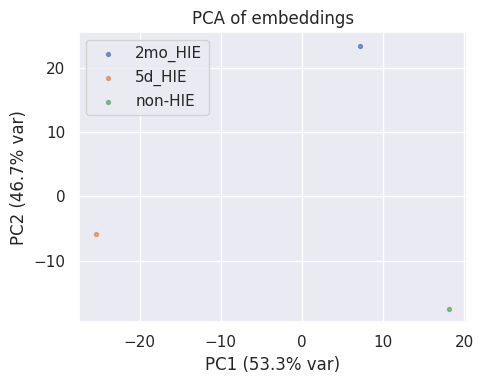

PCA coords saved. Preview:


,PC1,PC2,state
0,-25.308901,-5.917567,5d_HIE
1,18.128714,-17.560009,non-HIE
2,7.180184,23.477577,2mo_HIE


In [13]:
print("The analysis on the state embeddings:")

# STEP 1 — Imports

import os, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# STEP 2 — Prepare paths/names

prefix = f"{CONFIG['output_prefix']}_states"
emb_dir = Path(output_dir) / "state_embeddings"
emb_dir.mkdir(parents=True, exist_ok=True)

# Normalize embeddings to CPU NumPy (2D arrays)
import torch
import numpy as np
import pandas as pd
from pathlib import Path

prefix = f"{CONFIG['output_prefix']}_states"
emb_dir = Path(output_dir) / "state_embeddings"
emb_dir.mkdir(parents=True, exist_ok=True)

state_np = {}
for state, arr in state_embs_dict.items():
    # Convert possible Torch tensors (GPU or CPU) to NumPy
    if isinstance(arr, torch.Tensor):
        A = arr.detach().cpu().numpy()
    elif isinstance(arr, (list, tuple)) and len(arr) > 0 and isinstance(arr[0], torch.Tensor):
        A = torch.stack(arr).detach().cpu().numpy()
    else:
        A = np.asarray(arr)

    # Ensure 2D shape
    if A.ndim == 1:
        A = A.reshape(1, -1)

    state_np[state] = A

# STEP 3 — Save each state's embeddings to .npy and .csv 

for state, A in state_np.items():
    np.save(emb_dir / f"{prefix}_{state}.npy", A)
    pd.DataFrame(A).to_csv(emb_dir / f"{prefix}_{state}.csv", index=False)
print("Saved per-state embeddings.")

# STEP 4 — Build combined matrix + labels; save
X_list, labels = [], []
for state, A in state_np.items():
    X_list.append(A)
    labels += [state] * A.shape[0]

X = np.vstack(X_list)
combined = pd.DataFrame(X)
combined["state"] = labels
np.save(emb_dir / f"{prefix}_all.npy", X)
combined.to_csv(emb_dir / f"{prefix}_all.csv", index=False)
print("Saved combined embeddings.")

# STEP 5 — Cosine-similarity heatmap of STATE MEANS
import matplotlib.pyplot as plt

states = list(state_np.keys())
means = np.stack([A.mean(axis=0) for A in state_np.values()], axis=0)

# cosine similarity without external deps
norms = np.linalg.norm(means, axis=1, keepdims=True) + 1e-12
C = (means / norms) @ (means / norms).T

plt.figure(figsize=(4, 3))
im = plt.imshow(C, vmin=0, vmax=1)
plt.xticks(range(len(states)), states, rotation=45, ha="right")
plt.yticks(range(len(states)), states)
plt.title("Cosine similarity of state means")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(emb_dir / f"{prefix}_cosine_heatmap.png", dpi=200)
plt.close()
print("Saved cosine-similarity heatmap.")

# STEP 6 — PCA scatter 

from IPython.display import display
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if X.shape[0] >= 3:
    pca = PCA(n_components=2, random_state=73)
    Xp = pca.fit_transform(X)

    # Plot (SHOW + save)
    plt.figure(figsize=(5, 4))
    for s in sorted(set(labels)):
        m = (np.array(labels) == s)
        plt.scatter(Xp[m, 0], Xp[m, 1], s=8, alpha=0.7, label=s)
    plt.legend()
    plt.title("PCA of embeddings")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    plt.tight_layout()
    plt.show()  # ⬅️ display inline
    plt.savefig(emb_dir / f"{prefix}_pca.png", dpi=200)
    plt.close()

    # Save coordinates + preview
    pca_df = pd.DataFrame({"PC1": Xp[:, 0], "PC2": Xp[:, 1], "state": labels})
    pca_df.to_csv(emb_dir / f"{prefix}_pca.csv", index=False)
    np.save(emb_dir / f"{prefix}_pca.npy", Xp)
    print("PCA coords saved. Preview:")
    display(pca_df.head())
else:
    print("Skipped PCA: need ≥3 rows in X.")


In [14]:
# create the output files 

try:
    with open(CONFIG["token_dictionary_file"], "rb") as f:
        tok = pickle.load(f)
    keys = set(tok.keys()) if isinstance(tok, dict) else set()
    vals = set(tok.values()) if isinstance(tok, dict) else set()
    missing = [g for g in genes_to_perturb if g not in keys and g not in vals]
    if missing:
        print("⚠️ WARNING: not found in token dictionary:", missing)
except Exception as e:
    print("ℹ️ Skipping token-dict validation:", e)

# Output folders
isp_output_dir = os.path.join(output_dir, "isp")
isp_stats_dir  = os.path.join(output_dir, "isp_stats")
os.makedirs(isp_output_dir, exist_ok=True)
os.makedirs(isp_stats_dir, exist_ok=True)

ℹ️ Skipping token-dict validation: name 'genes_to_perturb' is not defined


In [15]:
# Your genes list
GENES = [
    "ENSG00000041415", "ENSG00000183098", "ENSG00000089225", "ENSG00000081189",
    "ENSG00000118058", "ENSG00000164199", "ENSG00000112658", "ENSG00000126353",
    "ENSG00000054598", "ENSG00000052904", "ENSG00000150907", "ENSG00000118689",
    "ENSG00000131196", "ENSG00000101096", "ENSG00000101097", "ENSG00000109320",
    "ENSG00000173039", "ENSG00000177606", "ENSG00000170345", "ENSG00000135917",
    "ENSG00000115414", "ENSG00000164093", "ENSG00000186951", "ENSG00000132170",
    "ENSG00000106462", "ENSG00000116044", "ENSG00000175387", "ENSG00000166949",
    "ENSG00000141646", "ENSG00000122691", "ENSG00000124216", "ENSG00000136826",
    "ENSG00000102554", "ENSG00000092929", "ENSG00000069592", "ENSG00000118526"
]

# To get valid TFs:
valid_GENES = set(token_df["Ensembl_ID"]).intersection(GENES)
print(f"✅ Valid GENES: {len(valid_GENES)}")
print(f"�� Use: {list(valid_GENES)}")

genes_to_perturb = valid_GENES
print(valid_GENES)

# genes_raw = genes_to_perturb
# genes_to_perturb = genes_raw
genes_raw = valid_GENES
print(genes_raw)

✅ Valid GENES: 32
�� Use: ['ENSG00000112658', 'ENSG00000106462', 'ENSG00000126353', 'ENSG00000175387', 'ENSG00000164199', 'ENSG00000135917', 'ENSG00000081189', 'ENSG00000141646', 'ENSG00000054598', 'ENSG00000109320', 'ENSG00000186951', 'ENSG00000124216', 'ENSG00000173039', 'ENSG00000092929', 'ENSG00000132170', 'ENSG00000102554', 'ENSG00000116044', 'ENSG00000164093', 'ENSG00000183098', 'ENSG00000122691', 'ENSG00000118526', 'ENSG00000118058', 'ENSG00000150907', 'ENSG00000177606', 'ENSG00000170345', 'ENSG00000089225', 'ENSG00000115414', 'ENSG00000131196', 'ENSG00000118689', 'ENSG00000101096', 'ENSG00000166949', 'ENSG00000136826']
{'ENSG00000112658', 'ENSG00000106462', 'ENSG00000126353', 'ENSG00000175387', 'ENSG00000164199', 'ENSG00000135917', 'ENSG00000081189', 'ENSG00000141646', 'ENSG00000054598', 'ENSG00000109320', 'ENSG00000186951', 'ENSG00000124216', 'ENSG00000173039', 'ENSG00000092929', 'ENSG00000132170', 'ENSG00000102554', 'ENSG00000116044', 'ENSG00000164093', 'ENSG00000183098', 'EN

In [16]:
# genes_raw = ['ENSG00000136574', 'ENSG00000183098', 'ENSG00000089225'] 
genes_raw = ["ENSG00000186951", "ENSG00000116044", "ENSG00000081189"]
genes_raw = [str(gene).strip() for gene in genes_raw]
print("Genes to perturb:", genes_raw)

Genes to perturb: ['ENSG00000186951', 'ENSG00000116044', 'ENSG00000081189']


In [17]:
##########################################################################################
##########################################################################################
# Target genes (Ensembl IDs) 
# genes_raw = ["ENSG00000186951", "ENSG00000116044", "ENSG00000081189"]

# Verify the genes
for gene in genes_raw:
    if gene in token_dict:
        token_id = token_dict[gene]
        print(f"✅ {gene} -> {token_id} ({type(token_id)})")
    else:
        print(f"❌ {gene} not found in token dictionary")

        
def strip_ver(x):  # ENSG00000123456.12 -> ENSG00000123456
    return x.split('.')[0]

# --- Load token dictionary
import pickle
with open(CONFIG["token_dictionary_file"], "rb") as f:
    token_dict = pickle.load(f)  # maps Ensembl (or symbols) -> token_id

# --- Data cleaning and verify with the token dict
genes_norm = [strip_ver(g) for g in genes_raw]
missing_in_dict = [g for g in genes_norm if g not in token_dict]
if missing_in_dict:
    raise RuntimeError(
        f"The following Ensembl IDs are not in the token dictionary: {missing_in_dict}\n"
        "→ Use a matching token_dictionary_file or retokenize."
    )

# --- Map Ensembl -> token ids
id2tok = {g: token_dict[g] for g in genes_norm}

# --- Verify these genes actually appear in the dataset (at least one cell)
from datasets import load_from_disk
dataset = load_from_disk(CONFIG["input_data_file"])

present_counts = {g: 0 for g in id2tok}
for ids in dataset["input_ids"]:
    s = set(ids)
    for g, t in id2tok.items():
        if t in s:
            present_counts[g] += 1

print("Cells containing each target gene:", present_counts)

genes_to_perturb = [g for g, cnt in present_counts.items() if cnt > 100] # number of cells higher than 10
if not genes_to_perturb:
    raise RuntimeError(
        "None of the requested genes appear in any cell; nothing to perturb.\n"
        "→ Pick more frequent genes or retokenize with a longer sequence length."
    )

print("Using genes_to_perturb =", genes_to_perturb)

✅ ENSG00000186951 -> 15606 (<class 'int'>)
✅ ENSG00000116044 -> 4487 (<class 'int'>)
✅ ENSG00000081189 -> 1524 (<class 'int'>)
Cells containing each target gene: {'ENSG00000186951': 337, 'ENSG00000116044': 551, 'ENSG00000081189': 859}
Using genes_to_perturb = ['ENSG00000186951', 'ENSG00000116044', 'ENSG00000081189']


In [18]:
# print(dataset["input_ids"])
print(CONFIG["input_data_file"])

# Output folders
isp_output_dir = os.path.join(output_dir, "isp")
isp_stats_dir  = os.path.join(output_dir, "isp_stats")
os.makedirs(isp_output_dir, exist_ok=True)
os.makedirs(isp_stats_dir, exist_ok=True)

/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.dataset


In [19]:
# === Geneformer ===
from geneformer import EmbExtractor, Classifier, InSilicoPerturber, InSilicoPerturberStats
import pickle


In [20]:
# genes_to_perturb = ['ENSG00000081189', 'ENSG00000186951', 'ENSG00000116044', 'ENSG00000115414', 'ENSG00000175387', 'ENSG00000164199', 'ENSG00000106462', 'ENSG00000141646', 'ENSG00000170345', 'ENSG00000118689', 'ENSG00000109320', 'ENSG00000102554', 'ENSG00000118058', 'ENSG00000150907', 'ENSG00000134954']

In [21]:
print(f"🧬 Starting ISP analysis for {len(genes_to_perturb)} genes...")
print("=" * 60)

# Track results and errors
successful_genes = []
failed_genes = []
total_start_time = time.time()

for i, gene in enumerate(genes_to_perturb, 1):
    print(f"\n Processing gene {i}/{len(genes_to_perturb)}: {gene}")
    print("-" * 50)
    
    try:
        # Time the ISP initialization for this gene
        print(f" Initializing InSilicoPerturber for {gene}...")
        init_start = time.time()
        
        isp = InSilicoPerturber(
            perturb_type="delete",
            perturb_rank_shift=None,
            genes_to_perturb=[gene],  # Single gene
            combos=0,
            anchor_gene=None,
            model_type="CellClassifier",
            num_classes=3,
            emb_mode="cls",
            filter_data=filter_data_dict,
            cell_states_to_model=cell_states_to_model,
            state_embs_dict=state_embs_dict,
            max_ncells=1200,
            emb_layer=0,
            forward_batch_size=32,
            model_version="V2",
            nproc=10
        )
        
        init_time = time.time() - init_start
        print(f"✅ ISP initialized for {gene} in {init_time:.2f} seconds")
        
        # Time the perturbation execution for this gene
        print(f"🧬 Running ISP perturbation for {gene}...")
        perturb_start = time.time()
        
        # Create gene-specific output directory
        gene_output_dir = os.path.join(isp_output_dir, f"gene_{gene}")
        gene_stats_dir = os.path.join(isp_stats_dir, f"gene_{gene}")
        os.makedirs(gene_output_dir, exist_ok=True)
        os.makedirs(gene_stats_dir, exist_ok=True)
        
        isp.perturb_data(
            CONFIG["model_path"],
            CONFIG["input_data_file"],
            gene_output_dir,
            f"{CONFIG['output_prefix']}_{gene}"
        )
        
        perturb_time = time.time() - perturb_start
        total_time = time.time() - init_start
        
        print(f"✅ ISP outputs for {gene} -> {gene_output_dir}")
        print(f"⏱️ Perturbation time for {gene}: {perturb_time:.2f} seconds ({perturb_time/60:.2f} minutes)")
        print(f"⏱️ Total time for {gene}: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
        
        # Goal-state-shift statistics for this gene
        print(f" Initializing InSilicoPerturberStats for {gene}...")
        stats_init_start = time.time()
        
        ispstats = InSilicoPerturberStats(
            mode="goal_state_shift",
            genes_perturbed=[gene],
            combos=0,
            anchor_gene=None,
            cell_states_to_model=cell_states_to_model,
            model_version="V2",
            token_dictionary_file=token_dictionary_file
        )

        stats_init_time = time.time() - stats_init_start
        total_time_with_stats = time.time() - init_start
        
        print(f"✅ InSilicoPerturberStats initialized for {gene} in {stats_init_time:.2f} seconds")
        print(f"⏱️ Total time for {gene} (init + execution + stats_init): {total_time_with_stats:.2f} seconds ({total_time_with_stats/60:.2f} minutes)")
        
        # Time the statistics computation for this gene
        print(f"📈 Computing statistics for {gene}...")
        stats_comp_start = time.time()
        
        ispstats.get_stats(
            gene_output_dir,  # Use gene-specific output directory
            None,
            gene_stats_dir,   # Use gene-specific stats directory
            f"{CONFIG['output_prefix']}_{gene}"
        )
        
        stats_comp_time = time.time() - stats_comp_start
        total_gene_time = time.time() - init_start
        
        print(f"✅ Statistics computed for {gene} -> {gene_stats_dir}")
        print(f"⏱️ Statistics computation time for {gene}: {stats_comp_time:.2f} seconds ({stats_comp_time/60:.2f} minutes)")
        print(f"⏱️ Total time for {gene}: {total_gene_time:.2f} seconds ({total_gene_time/60:.2f} minutes)")
        
        # Mark as successful
        successful_genes.append(gene)
        print(f"✅ Gene {gene} completed successfully!")
        
    except Exception as e:
        # Enhanced error logging with line numbers
        import traceback
        error_msg = f"❌ Error processing gene {gene}: {str(e)}"
        print(error_msg)
        print("Full error traceback:")
        traceback.print_exc()
        
        # Log to file
        log_file = os.path.join(output_dir, "gene_processing_errors.log")
        with open(log_file, 'a') as f:
            timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            f.write(f"[{timestamp}] {error_msg}\n")
            f.write(f"Traceback:\n{traceback.format_exc()}\n")
        
        failed_genes.append(gene)
        print(f"⚠️ Continuing with next gene...")
        continue

# Final summary
total_end_time = time.time()
total_elapsed = total_end_time - total_start_time

print("\n" + "=" * 60)
print("🏁 GENE PROCESSING SUMMARY")
print("=" * 60)
print(f"📊 Total genes processed: {len(genes_to_perturb)}")
print(f"✅ Successful genes: {len(successful_genes)}")
print(f"❌ Failed genes: {len(failed_genes)}")
print(f"⏱️ Total elapsed time: {total_elapsed:.2f} seconds ({total_elapsed/60:.2f} minutes)")

if failed_genes:
    print(f"\n❌ Failed genes:")
    for gene in failed_genes:
        print(f"  - {gene}")
    
    print(f"\n Check error log: {os.path.join(output_dir, 'gene_processing_errors.log')}")

🧬 Starting ISP analysis for 3 genes...

 Processing gene 1/3: ENSG00000186951
--------------------------------------------------
 Initializing InSilicoPerturber for ENSG00000186951...
✅ ISP initialized for ENSG00000186951 in 0.00 seconds
🧬 Running ISP perturbation for ENSG00000186951...


num_proc must be <= 5. Reducing num_proc to 5 for dataset of size 5.


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

✅ ISP outputs for ENSG00000081189 -> /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827150025/isp/gene_ENSG00000081189
⏱️ Perturbation time for ENSG00000081189: 56.07 seconds (0.93 minutes)
⏱️ Total time for ENSG00000081189: 56.07 seconds (0.93 minutes)
 Initializing InSilicoPerturberStats for ENSG00000081189...
✅ InSilicoPerturberStats initialized for ENSG00000081189 in 0.01 seconds
⏱️ Total time for ENSG00000081189 (init + execution + stats_init): 56.09 seconds (0.93 minutes)
📈 Computing statistics for ENSG00000081189...


  0%|          | 0/1 [00:00<?, ?it/s]

✅ Statistics computed for ENSG00000081189 -> /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827150025/isp_stats/gene_ENSG00000081189
⏱️ Statistics computation time for ENSG00000081189: 0.01 seconds (0.00 minutes)
⏱️ Total time for ENSG00000081189: 56.10 seconds (0.93 minutes)
✅ Gene ENSG00000081189 completed successfully!

🏁 GENE PROCESSING SUMMARY
📊 Total genes processed: 3
✅ Successful genes: 3
❌ Failed genes: 0
⏱️ Total elapsed time: 105.56 seconds (1.76 minutes)


In [23]:
# Examine the pickle files : to fix !!

In [24]:
print(isp_output_dir)

/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827150025/isp


In [25]:
# Do not run it yet !

In [26]:
# the old code to run transcriptome-wide ISP

In [27]:
print(output_dir)
print(isp_output_dir)
print(isp_stats_dir)

/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827150025
/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827150025/isp
/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827150025/isp_stats


In [28]:
genes_to_perturb = "all"

import time

# Time the ISP initialization
print("�� Initializing InSilicoPerturber...")
init_start = time.time()

isp = InSilicoPerturber(
    perturb_type = "delete",
    perturb_rank_shift = None,
    genes_to_perturb = genes_to_perturb,
    # genes_to_perturb = "all",
    combos = 0,
    anchor_gene = None,
    model_type = "CellClassifier",
    num_classes = 3,
    emb_mode = "cls",                     # ✅ Use CLS embedding for V2
    # emb_mode = "cell",                    # SET TO "CELL" FOR V1 MODEL. FOR V2, SHOULD BE "CLS" (current default).
    # emb_mode = "cls_and_gene",
    filter_data = filter_data_dict,
    cell_states_to_model = cell_states_to_model,
    state_embs_dict = state_embs_dict,
    max_ncells = 1200,
    emb_layer = 0,
    forward_batch_size = 32,
    model_version = "V2",                 # ✅ Matches CLS usage
    nproc = 130
)

# --- avoid the Column * int bug by skipping the special-token code path ---
if hasattr(isp, "special_token"):
    isp.special_token = False

# Time the perturbation execution
print("🧬 Running ISP perturbation...")
perturb_start = time.time()

isp.perturb_data(
    CONFIG["model_path"],
    CONFIG["input_data_file"],
    isp_output_dir,
    f"{CONFIG['output_prefix']}_tf"
)

perturb_time = time.time() - perturb_start
total_time = time.time() - init_start

print(f"✅ ISP outputs -> {isp_output_dir}")
print(f"⏱️ Perturbation execution time: {perturb_time:.2f} seconds ({perturb_time/60:.2f} minutes)")
print(f"⏱️ Total time (init + execution): {total_time:.2f} seconds ({total_time/60:.2f} minutes)")

# Goal-state-shift statistics (Chronic → Normoxia, Acute as alt)
print("�� Initializing InSilicoPerturberStats...")
stats_init_start = time.time()

ispstats = InSilicoPerturberStats(
    mode="goal_state_shift",
    genes_perturbed = genes_to_perturb,
    combos = 0,
    anchor_gene = None,
    cell_states_to_model = cell_states_to_model,
    model_version = "V2",
    token_dictionary_file = token_dictionary_file
)

stats_init_time = time.time() - stats_init_start
total_time_with_stats = time.time() - init_start

print(f"✅ InSilicoPerturberStats initialized in {stats_init_time:.2f} seconds")
print(f"⏱️ Total time (init + execution + stats_init): {total_time_with_stats:.2f} seconds ({total_time_with_stats/60:.2f} minutes)")

# Time the statistics computation
print("📈 Computing statistics...")
stats_comp_start = time.time()

ispstats.get_stats(
    isp_output_dir,
    None,
    isp_stats_dir,
    f"{CONFIG['output_prefix']}_genes"
)

stats_comp_time = time.time() - stats_comp_start

print(f"✅ Statistics computed -> {isp_stats_dir}")
print(f"⏱️ Statistics computation time: {stats_comp_time:.2f} seconds ({stats_comp_time/60:.2f} minutes)")

�� Initializing InSilicoPerturber...
🧬 Running ISP perturbation...


  0%|          | 0/83 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/128 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

✅ ISP outputs -> /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827150025/isp
⏱️ Perturbation execution time: 29892.68 seconds (498.21 minutes)
⏱️ Total time (init + execution): 29892.69 seconds (498.21 minutes)
�� Initializing InSilicoPerturberStats...
✅ InSilicoPerturberStats initialized in 0.02 seconds
⏱️ Total time (init + execution + stats_init): 29892.70 seconds (498.21 minutes)
📈 Computing statistics...


  0%|          | 0/169 [00:00<?, ?it/s]

  0%|          | 0/12196 [00:00<?, ?it/s]

  0%|          | 0/12196 [00:00<?, ?it/s]

✅ Statistics computed -> /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827150025/isp_stats
⏱️ Statistics computation time: 543.52 seconds (9.06 minutes)


In [29]:
# After ISP execution, automatically load results from isp_output_dir
print(f"📁 Loading ISP results from: {isp_output_dir}")

# Look for pickle files in the isp_output_dir
import glob
pickle_files = glob.glob(os.path.join(isp_output_dir, "*_raw.pickle"))

if pickle_files:
    # Use the most recent file (in case there are multiple)
    latest_pickle = max(pickle_files, key=os.path.getctime)
    print(f"✅ Found ISP results: {os.path.basename(latest_pickle)}")
    
    # Load automatically
    with open(latest_pickle, 'rb') as f:
        data = pickle.load(f)
    
    print(f"\n📊 File contents:")
    print(f"Type: {type(data)}")
    
    if isinstance(data, dict):
        print(f"Keys: {list(data.keys())}")
        
        # Explore the structure
        for key, value in data.items():
            print(f"\n--- {key} ---")
            print(f"  Type: {type(value)}")
            
            if isinstance(value, dict):
                print(f"  Dict keys: {list(value.keys())}")
                for sub_key, sub_value in value.items():
                    print(f"    {sub_key}: {type(sub_value)}")
                    if hasattr(sub_value, 'shape'):
                        print(f"      Shape: {sub_value.shape}")
                    elif isinstance(sub_value, list):
                        print(f"      Length: {len(sub_value)}")
                        print(f"      First 5 values: {sub_value[:5]}")
            elif hasattr(value, 'shape'):
                print(f"  Shape: {value.shape}")
            elif isinstance(value, list):
                print(f"  Length: {len(value)}")
                print(f"  First 10 values: {value[:10]}")
                print(f"  Last 5 values: {value[-5:]}")
    else:
        print(f"Content: {data}")
    
    # Store in perturbation_results for later use
    perturbation_results = data
    print(f"\n🎯 Results loaded into 'perturbation_results' variable!")
    
else:
    print(f"❌ No ISP results found in {isp_output_dir}")
    print(f"Available files:")
    for f in sorted(os.listdir(isp_output_dir)):
        print(f"  {f}")
    perturbation_results = None

📁 Loading ISP results from: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827150025/isp
✅ Found ISP results: in_silico_delete_hypoxia_2000cells_ISP_tf_dict_cell_embs_82batch0_raw.pickle

📊 File contents:
Type: <class 'dict'>
Keys: ['5d_HIE', 'non-HIE', '2mo_HIE']

--- 5d_HIE ---
  Type: <class 'collections.defaultdict'>
  Dict keys: [(7160, 'cell_emb'), (8816, 'cell_emb'), (2800, 'cell_emb'), (15017, 'cell_emb'), (5665, 'cell_emb'), (9923, 'cell_emb'), (8207, 'cell_emb'), (5374, 'cell_emb'), (8087, 'cell_emb'), (5257, 'cell_emb'), (13685, 'cell_emb'), (15074, 'cell_emb'), (16281, 'cell_emb'), (19639, 'cell_emb'), (7561, 'cell_emb'), (229, 'cell_emb'), (10091, 'cell_emb'), (7630, 'cell_emb'), (6092, 'cell_emb'), (335, 'cell_emb'), (6649, 'cell_emb'), (12308, 'cell_emb'), (16097, 'cell_emb'), (1327, 'cell_emb'), (4127, 'cell_emb'), (3447, 'cell_emb'), (6994, 'cell_emb'), (5595, 'cell_emb'), (7266, 'cell_emb'), 